# Predicting Health Insurance Costs

This notebook follows a standard machine learning workflow.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
df = pd.read_csv("insurance.csv")

## 3. Exploratory Data Analysis (EDA)

In [3]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [5]:
df.shape

(1340, 10)

In [6]:
pd.set_option("display.float_format", "{:,.2f}".format)

In [7]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,"1,121.87"
1,2,24.00,male,30.10,87,No,0,No,southeast,"1,131.51"
2,3,NaN,male,33.30,82,Yes,0,No,southeast,"1,135.94"
3,4,NaN,male,33.70,80,No,0,No,northwest,"1,136.40"
4,5,NaN,male,34.10,100,No,0,No,northwest,"1,137.01"
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,"55,135.40"
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,"58,571.07"
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,"60,021.40"
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,"62,592.87"


In [8]:
import seaborn as sns
sns.set(style="whitegrid",palette="Set2",font_scale=1.1)


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.shape

(1332, 10)

In [13]:
df.isna().sum()

Id               0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [14]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,"1,332.00","1,332.00",1332,"1,332.00","1,332.00",1332,"1,332.00",1332,1332,"1,332.00"
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,"13,325.25"
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,"12,109.62"
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,"1,121.87"
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,"4,760.16"
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,"9,412.97"
75%,"1,007.25",47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,"16,781.33"


In [15]:
numeric_cols = ["age", "bmi", "bloodpressure", "children", "claim"]

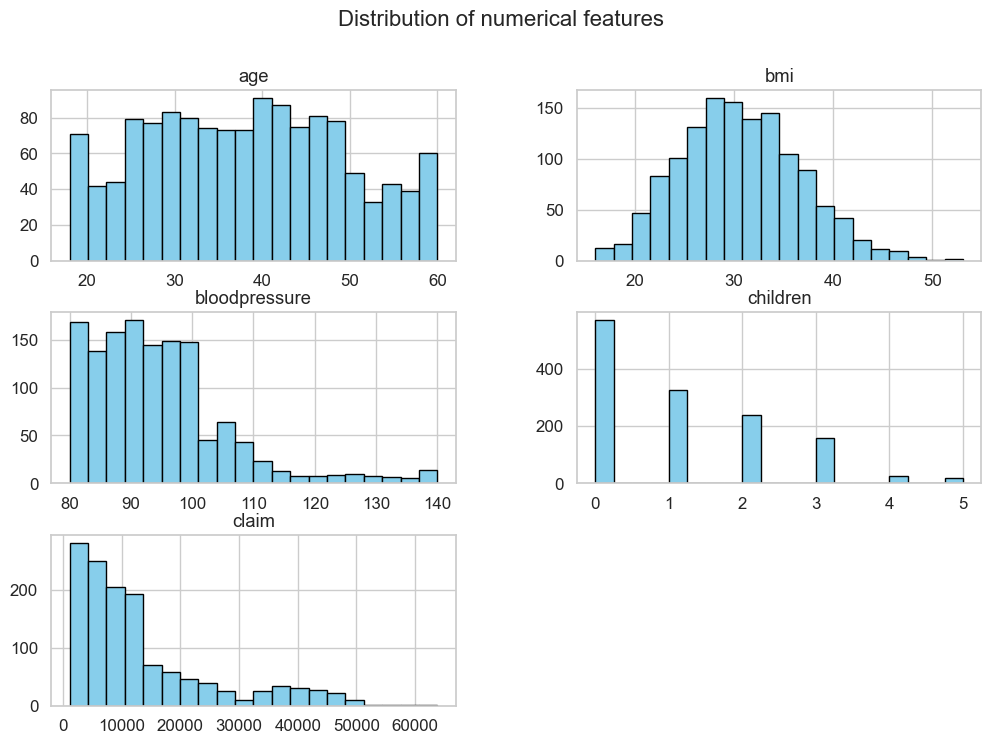

In [16]:
df[numeric_cols].hist(bins=20, figsize=(12, 8), color = "skyblue", edgecolor ="black")
plt.suptitle("Distribution of numerical features", fontsize=16)
plt.show()

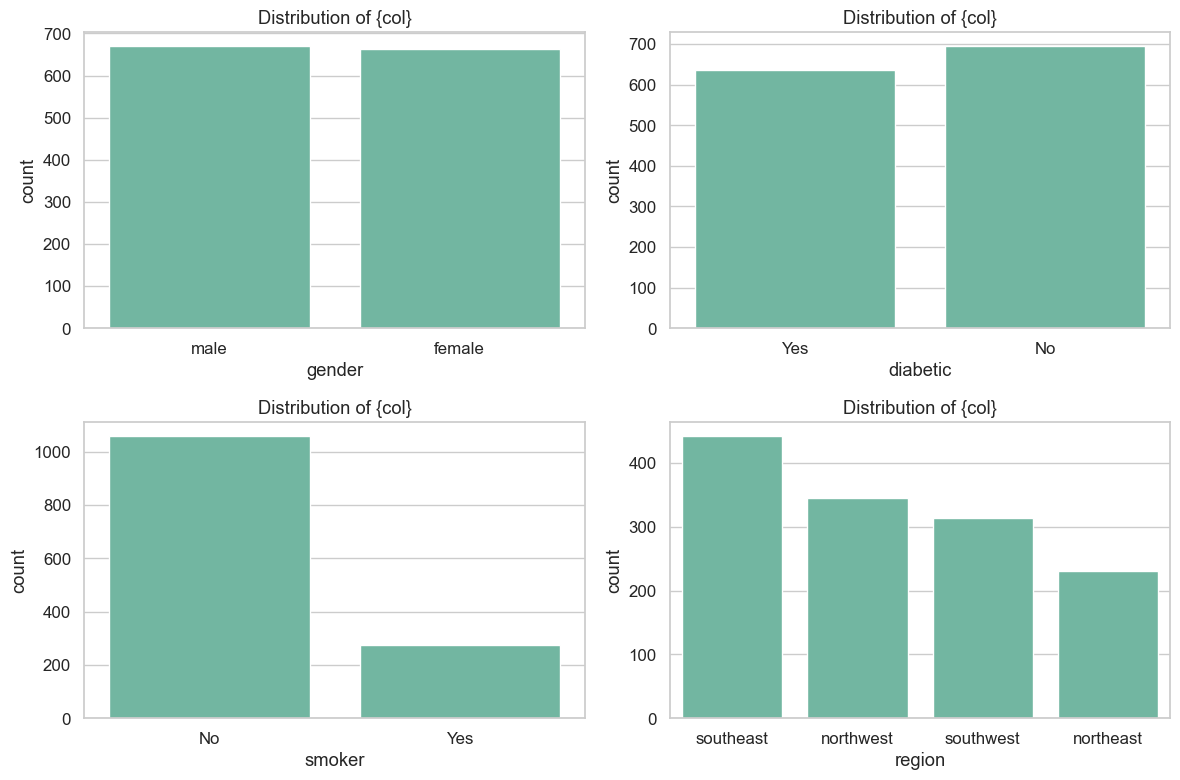

In [17]:
cat_cols = ["gender", "diabetic", "smoker", "region"]
plt.figure(figsize=(12, 8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x = col)
    plt.title("Distribution of {col}")
plt.tight_layout()
plt.show()

In [18]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8,762.30
        Yes      30,679.00
male    No        8,169.25
        Yes      33,042.01
Name: claim, dtype: float64

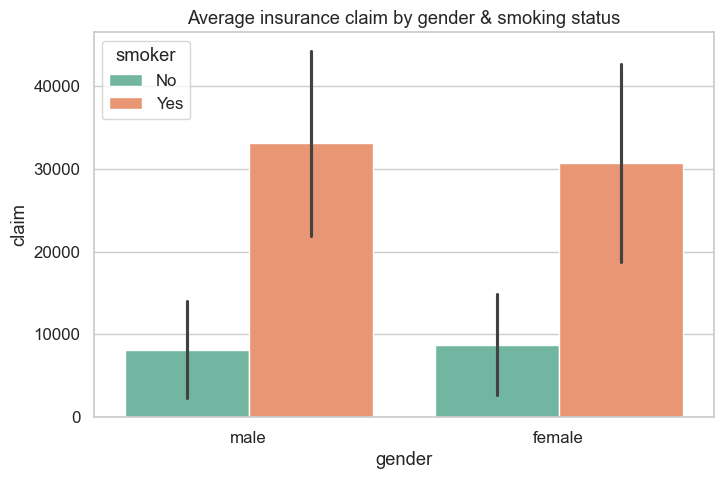

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="gender", y="claim", hue="smoker", estimator="mean", errorbar="sd")
plt.title("Average insurance claim by gender & smoking status")
plt.show()

In [20]:
pivot_region_diabatic = df.groupby(["region", "diabetic"])["claim"].mean().unstack()

In [21]:
pivot_region_diabatic

diabetic,No,Yes
region,,
northeast,"16,966.86","16,818.30"
northwest,"11,442.83","12,224.96"
southeast,"13,578.72","12,574.09"
southwest,"13,069.91","12,313.74"


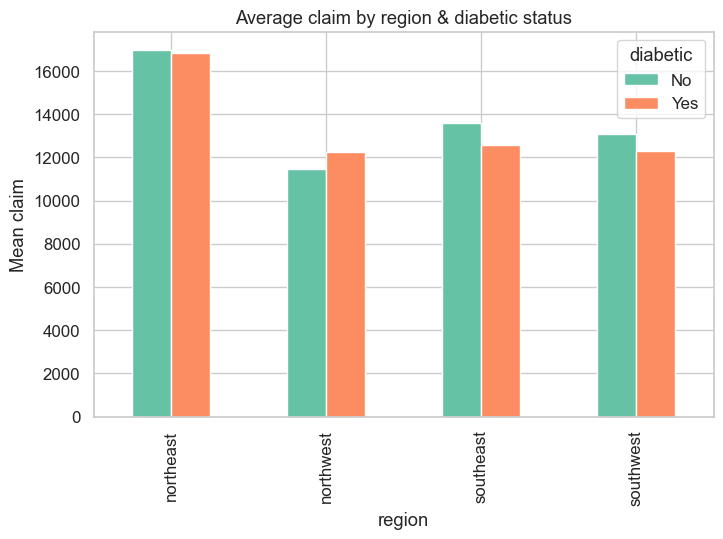

In [22]:
pivot_region_diabatic.plot(kind="bar", figsize=(8, 5))
plt.title("Average claim by region & diabetic status")
plt.ylabel("Mean claim")
plt.show()

In [23]:
pivot_table = pd.pivot_table(df, values="claim", index="region", columns="smoker", aggfunc="mean")
pivot_table

smoker,No,Yes
region,,
northeast,"11,666.11","29,673.54"
northwest,"8,076.20","30,192.00"
southeast,"7,444.14","34,845.00"
southwest,"8,294.75","32,269.06"


In [24]:
pivot_table = pd.pivot_table(df, values="claim", index="children", columns="diabetic", aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,"12,967.40","11,985.29"
1,"12,730.46","12,732.06"
2,"15,567.77","14,579.36"
3,"13,807.61","17,091.26"
4,"14,106.63","13,573.35"
5,"8,519.04","9,205.59"


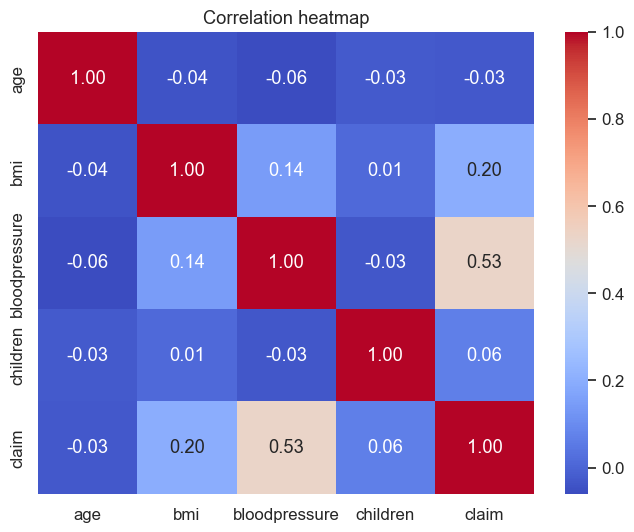

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

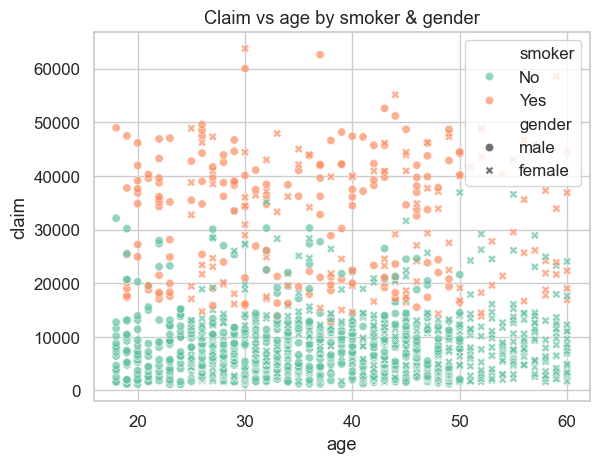

In [26]:
sns.scatterplot(data=df, x="age", y="claim", hue="smoker", style="gender", alpha=0.7)
plt.title("Claim vs age by smoker & gender")
plt.show()

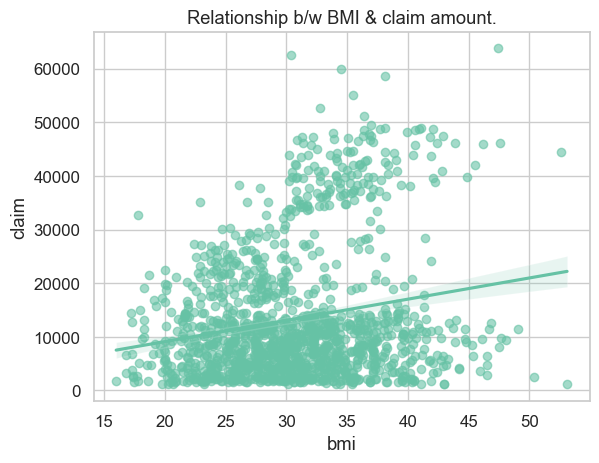

In [27]:
sns.regplot(data=df, x="bmi", y="claim", scatter_kws={"alpha": 0.6})
plt.title("Relationship b/w BMI & claim amount.")
plt.show()

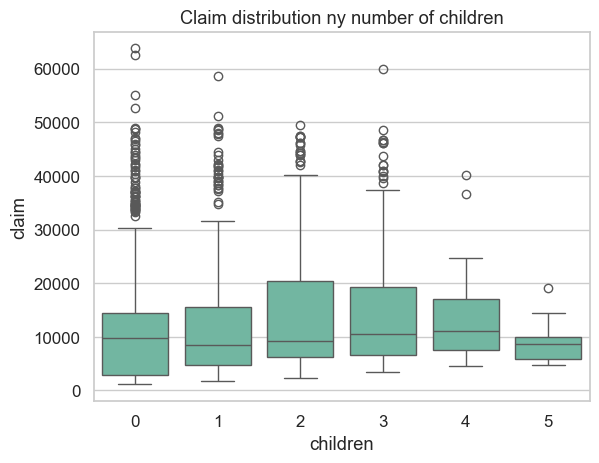

In [28]:
sns.boxplot(data=df, x="children", y="claim")
plt.title("Claim distribution ny number of children")
plt.show()

In [29]:
df["age_group"] = pd.cut(df["age"], bins=[0, 18, 30, 45, 60, 100], labels=["<18", "18-30","31-45", "45-60", "60+"])

In [30]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,"1,121.87",31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,"1,131.51",18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,"1,146.80",18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,"1,149.40",18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,"1,163.46",18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,"55,135.40",31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,"58,571.07",45-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,"60,021.40",18-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,"62,592.87",31-45


In [31]:
df["age_group"].value_counts()

age_group
31-45    553
45-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

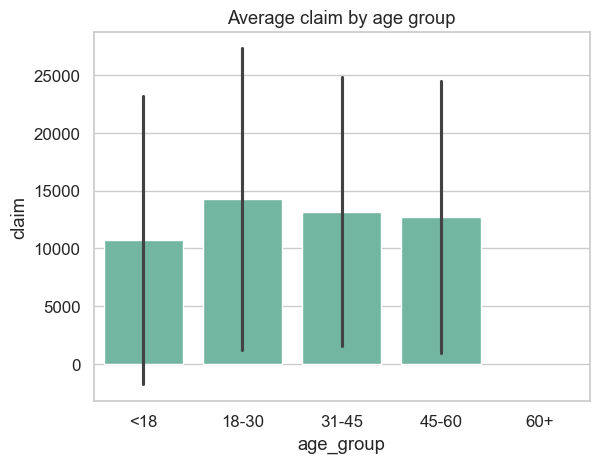

In [32]:
sns.barplot(data=df, x="age_group", y="claim", estimator="mean", errorbar="sd")
plt.title("Average claim by age group")
plt.show()

In [33]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 24.9, 29.9, 100], labels=["Underweight", "Normal","Overweight", "Obese"])

In [34]:
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

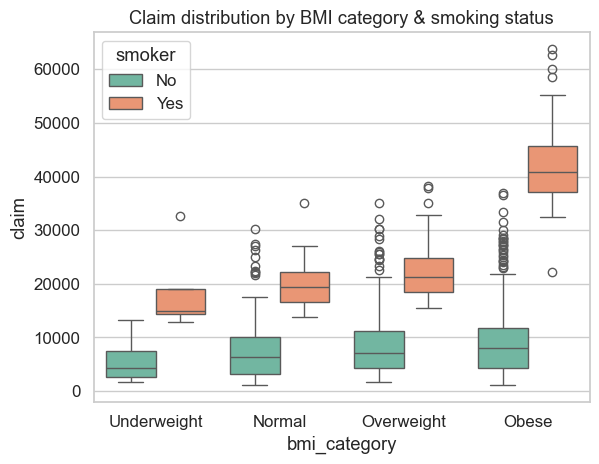

In [35]:
sns.boxplot(data=df, x="bmi_category", y="claim", hue="smoker")
plt.title("Claim distribution by BMI category & smoking status")
plt.show()

In [36]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x:(x=="yes").mean() * 100),
    mean_claim = ("claim", "mean")
).reset_index()

In [37]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,0.00,"16,889.04"
1,northwest,0.00,"11,794.22"
2,southeast,0.00,"13,085.50"
3,southwest,0.00,"12,723.13"


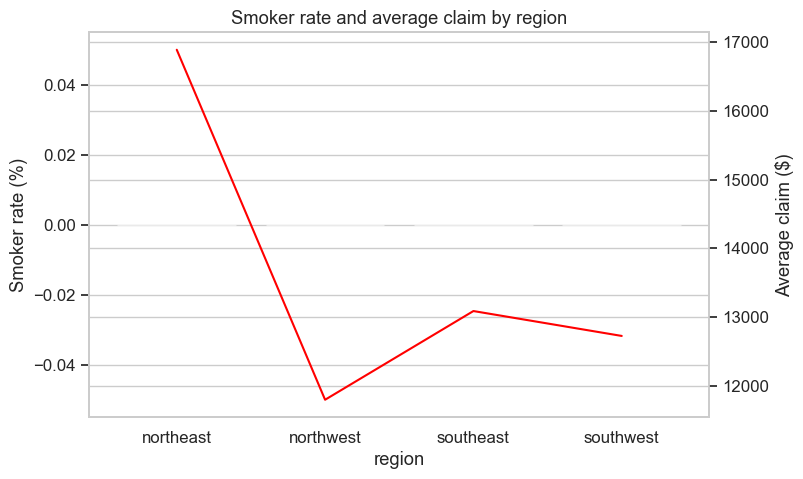

In [38]:
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(data=region_stats, x="region", y="smoker_rate", ax=ax1, alpha=0.6)
ax2 = ax1.twinx()
sns.lineplot(data=region_stats, x="region", y="mean_claim", ax=ax2, color = "red", markers= "o")

ax1.set_ylabel("Smoker rate (%)")
ax2.set_ylabel("Average claim ($)")
plt.title("Smoker rate and average claim by region")
plt.show()

## 4. Data Preprocessing

## 5. Feature Engineering

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [40]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [41]:
X = df[["age", "gender", "bmi", "bloodpressure", "diabetic", "children", "smoker"]]
y = df[["claim"]]

In [42]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [43]:
cat_cols = ["gender","diabetic","smoker"]
label_encoders = {}

## 8. Save Artifacts

In [44]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    
    joblib.dump(le, f"label_encoder_{col}.pkl")

In [45]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [46]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [48]:
num_cols = ["age", "bmi", "bloodpressure", "children"]
scaler = StandardScaler()

In [49]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [50]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [51]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065, 1)


In [52]:
print(X_test.shape, y_test.shape)

(267, 7) (267, 1)


## 7. Model Evaluation

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [54]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return {"R2": r2, "MAE": mae, "RMSE": rmse}

In [55]:
results = {}

## 6. Model Training

In [56]:
lr = LinearRegression()
lr.fit(X_train, y_train)

results["Linear Regression"] = evaluate_model(
    lr, X_train, X_test, y_train, y_test
)

print("Linear Regression model trained")

best_poly_model = None
best_poly_score = -np.inf

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)

    score = poly_lr.score(X_test_poly, y_test)

    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)
        
degree, poly, poly_lr = best_poly_model

results[f"Polynomial Regression (Degree {degree})"] = evaluate_model(
    poly_lr,
    poly.fit_transform(X_train),
    poly.transform(X_test),
    y_train,
    y_test
)

print("Polynomial Regression models are trained")

rf = RandomForestRegressor()
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)
print("Random forest training is completed, best parameters:", rf_grid.best_params_)

svr = SVR()
svr_params = {
    "kernel": ["rbf", "poly", "linear"],
    "C": [1, 10, 50],
    "epsilon": [0.1, 0.2, 0.5],
    "degree": [2, 3]
}

svr_grid = GridSearchCV(
    svr,
    svr_params,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)

svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_

results["SVR"] = evaluate_model(
    best_svr,
    X_train,
    X_test,
    y_train,
    y_test
)

print("SVR training is completed, best parameters:", svr_grid.best_params_)

xgb = XGBRegressor(objective="reg:squarederror")

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(
    best_xgb,
    X_train,
    X_test,
    y_train,
    y_test
)

print(
    "XGBoost training is completed, best parameters:",xgb_grid.best_params_
)

Linear Regression model trained
Polynomial Regression models are trained
Random forest training is completed, best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
SVR training is completed, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost training is completed, best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [57]:
results

{'Linear Regression': {'R2': 0.7065554193437815,
  'MAE': 5217.584067337928,
  'RMSE': np.float64(6918.620935823109)},
 'Polynomial Regression (Degree 2)': {'R2': 0.7981034938111183,
  'MAE': 4292.203651536103,
  'RMSE': np.float64(5738.797385854986)},
 'Random Forest': {'R2': 0.8067783481682893,
  'MAE': 4205.929393512856,
  'RMSE': np.float64(5614.15482523987)},
 'SVR': {'R2': 0.4798841950870898,
  'MAE': 6250.678791307525,
  'RMSE': np.float64(9210.994341953248)},
 'XGBoost': {'R2': 0.818581223487854,
  'MAE': 4017.224609375,
  'RMSE': np.float64(5439.98382350536)}}

In [58]:
results_df = pd.DataFrame(results).T.sort_values(by="R2", ascending=False)
results_df

,R2,MAE,RMSE
XGBoost,0.82,"4,017.22","5,439.98"
Random Forest,0.81,"4,205.93","5,614.15"
Polynomial Regression (Degree 2),0.80,"4,292.20","5,738.80"
Linear Regression,0.71,"5,217.58","6,918.62"
SVR,0.48,"6,250.68","9,210.99"


In [59]:
best_rf

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "Random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [61]:
best_r2 = results_df["R2"].max()

In [62]:
best_r2

0.818581223487854

In [63]:
top_model = results_df[results_df["R2"] == best_r2]

In [64]:
top_model

,R2,MAE,RMSE
XGBoost,0.82,"4,017.22","5,439.98"


In [65]:
best_model = models[top_model.index[0]]

In [66]:
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [67]:
joblib.dump(best_model, "best_model.pkl")
print(f"Best model selected: {top_model.index[0]}")

Best model selected: XGBoost
